In [6]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



In [7]:
#load dataset
[ds] = qml.data.load("other", name="linearly-separable")




ImportError: This feature requires the 'aiohttp', 'h5py' and 'fsspec' packages. They can be installed with:

 pip install aiohttp fsspec h5py

In [18]:
#Acces 8-dim subset
X_train = ds.train["8"]["inputs"]
Y_train = ds.train["8"]["labels"]
X_test = ds.test["8"]["inputs"]
Y_test = ds.test["8"]["labels"]

X_train = np.array(X_train, requires_grad=False)
Y_train = np.array(Y_train, requires_grad=False)
X_test  = np.array(X_test, requires_grad=False)
Y_test  = np.array(Y_test, requires_grad=False)

print(f"Loaded 8-Qubit Dataset. Train shape: {X_train.shape}")

#Configuration
n_qubits = 8
n_chips = 2
qubits_per_chip = 4

L = 4
r = 3
steps = 100
batch_size= 50
step_size = 0.1

print(f"Original Data Range: {X_train.min():.2f} to {X_train.max():.2f}")

NameError: name 'ds' is not defined

In [6]:
dev = qml.device("default.qubit", wires=qubits_per_chip)

def block_ansatz(data_segment, params, zetas):
    #encode 4 features
    for w in range(qubits_per_chip):
        qml.RY(data_segment[w], wires=w)
        qml.RZ(data_segment[w], wires=w)

    #processing layers
    for layer in range(r):
        for w in range(qubits_per_chip):
            qml.Rot(*params[layer][w], wires=w)

        #local entanglement
        for i in range(qubits_per_chip):
            for j in range(i+1, qubits_per_chip):
                qml.CZ(wires=[i, j])

    #Partition cut
    for w in range(qubits_per_chip):
        qml.RZ(zetas[w], wires=w)

@qml.qnode(dev)
def sub_circuit(data_segment, params, zetas):
    block_ansatz(data_segment, params, zetas)
    return qml.expval(qml.PauliZ(0))

In [7]:
def rpm_8qubit_model(weights, cut_weights, lambdas, bias, x):
    """
    weights: Standard circuit weights
    cut_weights: (L, n_chips, 4) - The learned cut parameters
    lambdas: (L,) - The mixing weights
    x: Input data (8 features)
    """
    prediction = 0
    
    # Loop over the parallel terms (The "Knitting")
    for l in range(L):
        
        # Chip 1 (Features 0-3)
        # Note: We slice x[0:4]
        val1 = sub_circuit(x[:4], weights[0], cut_weights[l, 0])
        
        # Chip 2 (Features 4-7) 
        # Note: We slice x[4:8]
        val2 = sub_circuit(x[4:], weights[1], cut_weights[l, 1])
        
        # Combine (Tensor Product Sim)
        term = val1 * val2
        
        # Weighted Sum
        prediction += lambdas[l] * term
        
    return prediction + bias

In [8]:
np.random.seed(42) # Reproducibility
w_shape = (n_chips, r, qubits_per_chip, 3)
z_shape = (L, n_chips, qubits_per_chip) 

# Initialize 0 to 2pi to avoid "Identity Block"
weights = np.random.uniform(0, 2*np.pi, w_shape, requires_grad=True)
zetas   = np.random.uniform(0, 2*np.pi, z_shape, requires_grad=True)
lambdas = np.random.randn(L, requires_grad=True) * 0.1
bias    = np.array(0.0, requires_grad=True)

opt = qml.AdamOptimizer(step_size)

#  5. Training Loop 
def get_acc(w, z, l, b, x_data, y_data):
    preds = [np.sign(rpm_8qubit_model(w, z, l, b, x)) for x in x_data]
    return np.mean(np.array(preds) == y_data)

def cost_fn(w, z, l, b, x_batch, y_batch):
    preds = [rpm_8qubit_model(w, z, l, b, x) for x in x_batch]
    return np.mean((np.array(preds) - y_batch) ** 2)

print(f"Starting RPM Training (LR={step_size}, Batch={batch_size})")

for i in range(1, steps + 1):
    # Batch Sampling
    idx = np.random.randint(0, len(X_train), batch_size)
    x_batch = X_train[idx]
    y_batch = Y_train[idx]
    
    # Step
    def closure(w, z, l, b): return cost_fn(w, z, l, b, x_batch, y_batch)
    (weights, zetas, lambdas, bias), loss = opt.step_and_cost(closure, weights, zetas, lambdas, bias)
    
    # Log every 10 steps
    if i % 10 == 0:
        train_acc = get_acc(weights, zetas, lambdas, bias, X_train, Y_train)
        test_acc  = get_acc(weights, zetas, lambdas, bias, X_test, Y_test)
        
        print(f"Iter {i:3d} | Batch Cost: {loss:.4f} | "
              f"Train acc: {train_acc:.3f} | Test acc: {test_acc:.3f}..........")

def get_accuracy(w, z, l, b, x_data, y_data):
    # Predict sign (-1 or +1) for the whole dataset
    preds = [np.sign(rpm_8qubit_model(w, z, l, b, x)) for x in x_data]
    # Compare with true labels
    return np.mean(np.array(preds) == y_data)


final_train = get_acc(weights, zetas, lambdas, bias, X_train,  Y_train)
final_test  = get_acc(weights, zetas, lambdas, bias, X_test, Y_test)
print("="*60)
print(f"Final Train Acc: {final_train:.3f}")
print(f"Final Test Acc : {final_test:.3f}")

Starting RPM Training (LR=0.1, Batch=50)
Iter  10 | Batch Cost: 0.6483 | Train acc: 0.796 | Test acc: 0.833..........
Iter  20 | Batch Cost: 0.3527 | Train acc: 0.838 | Test acc: 0.850..........
Iter  30 | Batch Cost: 0.4128 | Train acc: 0.875 | Test acc: 0.783..........
Iter  40 | Batch Cost: 0.4260 | Train acc: 0.850 | Test acc: 0.850..........
Iter  50 | Batch Cost: 0.2669 | Train acc: 0.883 | Test acc: 0.917..........
Iter  60 | Batch Cost: 0.4427 | Train acc: 0.887 | Test acc: 0.883..........
Iter  70 | Batch Cost: 0.5185 | Train acc: 0.875 | Test acc: 0.833..........
Iter  80 | Batch Cost: 0.3560 | Train acc: 0.863 | Test acc: 0.817..........
Iter  90 | Batch Cost: 0.3246 | Train acc: 0.892 | Test acc: 0.850..........
Iter 100 | Batch Cost: 0.4064 | Train acc: 0.871 | Test acc: 0.867..........
Final Train Acc: 0.871
Final Test Acc : 0.867


In [ ]:
import pandas as pd
import time

def run_grid_config(L_val, r_val, steps=50):
    print(f"Testing Config: L={L_val}, r={r_val} ... ", end="")
    start_time = time.time()
    
    # Define Local Model
    def local_rpm_model(w, z, l_params, b, x):
        pred = 0
        for i in range(L_val):
            val1 = sub_circuit(x[:4], w[0], z[i, 0])
            val2 = sub_circuit(x[4:], w[1], z[i, 1])
            pred += l_params[i] * (val1 * val2)
        return pred + b

    #Initialize
    np.random.seed(42)
    w_shape = (2, r_val, 4, 3)
    z_shape = (L_val, 2, 4)
    
    weights = np.random.uniform(0, 2*np.pi, w_shape, requires_grad=True)
    zetas   = np.random.uniform(0, 2*np.pi, z_shape, requires_grad=True)
    lambdas = np.random.randn(L_val, requires_grad=True) * 0.1
    bias    = np.array(0.0, requires_grad=True)
    
    opt = qml.AdamOptimizer(0.1)
    
    # 
    batch_size = 50  
    
    for i in range(steps):
        # 1. Randomly sample 50 indices
        idx = np.random.randint(0, len(X_train), batch_size)
        x_batch = X_train[idx]
        y_batch = Y_train[idx]

        # 2. Compute cost ONLY on that batch
        def closure(w, z, l, b):
            preds = [local_rpm_model(w, z, l, b, x) for x in x_batch]
            return np.mean((np.array(preds) - y_batch) ** 2)
            
        (weights, zetas, lambdas, bias), loss = opt.step_and_cost(closure, weights, zetas, lambdas, bias)
    # 

    #Evaluation (Still uses full Test Set)
    test_preds = [np.sign(local_rpm_model(weights, zetas, lambdas, bias, x)) for x in X_test]
    acc = np.mean(np.array(test_preds) == Y_test)
    
    duration = time.time() - start_time
    print(f"Done! ({duration:.0f}s) -> Acc: {acc:.1%}")
    return acc

# The Grid Search Loop 
results = []
print("--- Starting Full Grid Search ---")


# The Grid: We vary L (Complexity) and r (Depth)
L_values = [1, 2, 4, 8]  # How many parallel terms?
r_values = [1, 2]        # How deep are the chips? (1 or 2 layers)

for r in r_values:
    for L in L_values:
        # Run the experiment
        accuracy = run_grid_config(L_val=L, r_val=r, steps=50)
        
        # Save result
        results.append({
            "L (Terms)": L,
            "r (Layers)": r,
            "Accuracy": accuracy
        })

# 3. Display Results
df_results = pd.DataFrame(results)
# Create a Pivot Table 
pivot_table = df_results.pivot(index="r (Layers)", columns="L (Terms)", values="Accuracy")

print("\n=== FINAL GRID SEARCH REPORT ===")
print(pivot_table)
print("\n(Values show Test Accuracy. Higher is better.)")

--- Starting Full Grid Search ---
Testing Config: L=1, r=1 ... Done! (120s) -> Acc: 66.7%
Testing Config: L=2, r=1 ... Done! (245s) -> Acc: 60.0%
Testing Config: L=4, r=1 ... Done! (489s) -> Acc: 60.0%
Testing Config: L=8, r=1 ... Done! (1000s) -> Acc: 65.0%
Testing Config: L=1, r=2 ... Done! (198s) -> Acc: 75.0%
Testing Config: L=2, r=2 ... Done! (397s) -> Acc: 76.7%
Testing Config: L=4, r=2 ... Done! (837s) -> Acc: 75.0%
Testing Config: L=8, r=2 ... Done! (1790s) -> Acc: 81.7%

=== FINAL GRID SEARCH REPORT ===
L (Terms)                    1                   2     4                   8
r (Layers)                                                                  
1           0.6666666666666666                 0.6   0.6                0.65
2                         0.75  0.7666666666666667  0.75  0.8166666666666667

(Values show Test Accuracy. Higher is better.)


Running 5-Fold Cross-Validation...
Fold 1: Val Accuracy = 90.00%
Fold 2: Val Accuracy = 86.67%
Fold 3: Val Accuracy = 88.33%
Fold 4: Val Accuracy = 86.67%
Fold 5: Val Accuracy = 83.33%


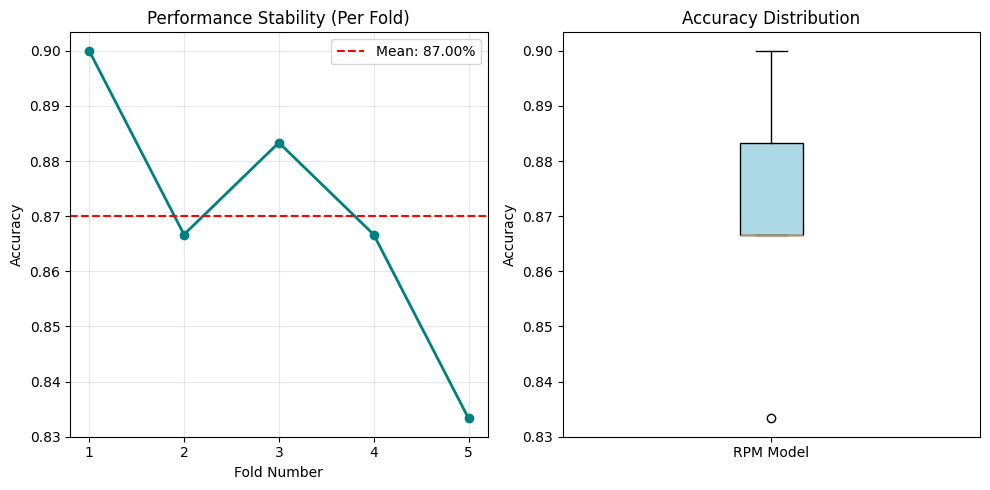


=== Cross-Validation Summary ===
Mean Accuracy: 87.00%
Standard Dev : 2.21%


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

# ==========================================
# 1. WRAPPER CLASS (Adapting your snippet)
# ==========================================
class RPMQuantumClassifier8Qubit(BaseEstimator, ClassifierMixin):
    def __init__(self, weights, zetas, lambdas, bias, predict_fn):
        # Store the TRAINED parameters
        self.weights = weights
        self.zetas = zetas
        self.lambdas = lambdas
        self.bias = bias
        self.predict_fn = predict_fn # Pass the prediction function
    
    def fit(self, X, y):
        # As per your snippet: Nothing to train here.
        # We are evaluating the stability of the FIXED trained model.
        return self
    
    def predict(self, X):
        # Calculate predictions using the passed RPM function
        preds = [
            self.predict_fn(self.weights, self.zetas, self.lambdas, self.bias, x)
            for x in X
        ]
        return np.sign(np.array(preds))

# ==========================================
# 2. SETUP DATA & MODEL
# ==========================================
# Combine Train and Test to validate on the full available data
# (Assuming X_train, X_test, Y_train, Y_test exist from previous cells)
X_full = np.concatenate([X_train, X_test])
Y_full = np.concatenate([Y_train, Y_test])

# Define the prediction helper if not already defined
# (This matches the logic used in your training loop)
def rpm_predict_wrapper(w, z, l, b, x):
    # This should match your 'rpm_8qubit_model' or 'model_predict' function
    return rpm_8qubit_model(w, z, l, b, x) 

# Create the wrapper instance

rpm_clf = RPMQuantumClassifier8Qubit(weights, zetas, lambdas, bias, rpm_predict_wrapper)

# 3. RUN CROSS-VALIDATION LOOP

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

print("Running 5-Fold Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_full, Y_full), start=1):
    # Split data
    X_val_cv = X_full[val_idx]
    Y_val_cv = Y_full[val_idx]
    
    # Predict (Using the fixed weights)
    Y_val_pred = rpm_8qubit_model(weights, zetas, lambdas, bias, X_val_cv)


for fold, (train_idx, val_idx) in enumerate(cv.split(X_full, Y_full), start=1):
    X_val_cv = X_full[val_idx]
    Y_val_cv = Y_full[val_idx]
    
    # Predict
    Y_val_pred = rpm_clf.predict(X_val_cv)
    
    # Score
    acc = accuracy_score(Y_val_cv, Y_val_pred)
    scores.append(acc)
    print(f"Fold {fold}: Val Accuracy = {acc:.2%}")

plt.figure(figsize=(10, 5))

# Plot: Accuracy per Fold
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), scores, marker='o', linestyle='-', color='teal', linewidth=2)
plt.axhline(np.mean(scores), color='red', linestyle='--', label=f'Mean: {np.mean(scores):.2%}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Performance Stability (Per Fold)')
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.legend()

# Plot: Distribution
plt.subplot(1, 2, 2)
plt.boxplot(scores, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Accuracy Distribution')
plt.ylabel('Accuracy')
plt.xticks([1], ['RPM Model'])

plt.tight_layout()
plt.show()

print("\n=== Cross-Validation Summary ===")
print(f"Mean Accuracy: {np.mean(scores):.2%}")
print(f"Standard Dev : {np.std(scores):.2%}")

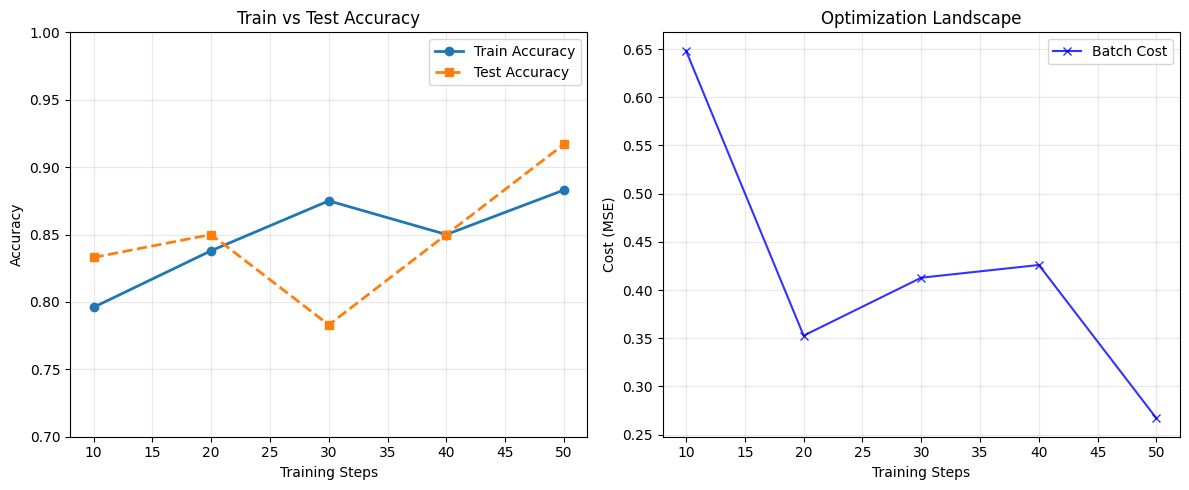

In [10]:
import matplotlib.pyplot as plt

# ==========================================
# 1. INPUT DATA (First 50 Iterations Only)
# ==========================================
iters = [10, 20, 30, 40, 50]
costs = [0.6483, 0.3527, 0.4128, 0.4260, 0.2669]
train_acc = [0.796, 0.838, 0.875, 0.850, 0.883]
test_acc = [0.833, 0.850, 0.783, 0.850, 0.917]

# ==========================================
# 2. PLOT GENERATION
# ==========================================
plt.figure(figsize=(12, 5))

# --- Left Plot: Accuracy (Train vs Test) ---
plt.subplot(1, 2, 1)
plt.plot(iters, train_acc, 'o-', label='Train Accuracy', color='#1f77b4', linewidth=2)
plt.plot(iters, test_acc, 's--', label='Test Accuracy', color='#ff7f0e', linewidth=2)

plt.xlabel("Training Steps")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

# --- Right Plot: Cost (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(iters, costs, 'x-', label='Batch Cost', color='blue', alpha=0.8)

plt.xlabel("Training Steps")
plt.ylabel("Cost (MSE)")
plt.title("Optimization Landscape")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()